In [378]:
import sys
sys.path.append("..")

import numpy as np

def ring_average(matrix, dist="chebyshev"):
    """
    基于距离的同心层平均
    """
    
    match dist:
        case "manhattan":
            distance = lambda x, y, c: abs(x - c) + abs(y - c)
        case "chebyshev":
            distance = lambda x, y, c: max(abs(x - c), abs(y - c))
    
    n = matrix.shape[0]
    if n % 2 == 0:
        raise ValueError("矩阵维度必须为奇数")
    
    result = matrix.copy().astype(float)
    center = n // 2
    max_layer = 2 * center  # 曼哈顿距离最大为 2*center（角落）
    
    for layer in range(max_layer + 1):
        indices = []
        # 收集该曼哈顿距离的所有坐标
        for i in range(n):
            for j in range(n):
                if distance(i, j, center) == layer:
                    indices.append((i, j))
        
        if indices:
            values = [matrix[i, j] for i, j in indices]
            avg = np.mean(values)
            for i, j in indices:
                result[i, j] = avg
                
    return result

In [379]:
# s = r"D:\Internship\bimsa\result\predictor_life_simple\2026-03-21_23-29-12_small_3_layer_seq_cnn__200-200-B3_S23\best_simple_life_SimpleCNNSmall_0.1.0.pth"
# s = r"D:\Internship\bimsa\result\predictor_life_simple\2026-03-14_14-57-31_small_3_layer_seq_cnn__200-200-B3678_S34678\best_simple_life_SimpleCNNSmall_0.1.0.pth"
s = r"D:\Internship\bimsa\result\predictor_life_simple\2026-03-22_19-17-31_small_3_layer_seq_p4cnn__200-200-R2_C0_M1_S3-7_B5-9_NB\best_simple_life_SimpleP4CNNSmall_0.5.0-p4.pth"
# s = r"D:\Internship\bimsa\result\predictor_life_simple\2026-03-22_21-13-04_small_3_layer_seq_p4cnn__200-200-R4_C0_M1_S41-81_B41-81_NM\best_simple_life_SimpleP4CNNSmall_0.5.0-p4.pth"

# s = r"/Users/heruijie/BIMSA/result/predictor_life_simple/2026-03-21_23-29-12_small_3_layer_seq_cnn__200-200-B3_S23/best_simple_life_SimpleCNNSmall_0.1.0.pth"
# s = r"/Users/heruijie/BIMSA/result/predictor_life_simple/2026-03-22_19-17-31_small_3_layer_seq_p4cnn__200-200-R2_C0_M1_S3-7_B5-9_NB/best_simple_life_SimpleP4CNNSmall_0.5.0-p4.pth"

In [380]:
from math import ceil
import os
import re
from collections import Counter

import numpy as np
import torch
from einops import rearrange

from dataloader import LifeGameDataset
import model_conv

p = re.compile(r".*?\\(?P<date>\d{4}(-\d\d){2})_(\d\d-){2}\d\d_.*?__(?P<n1>\d+)-(?P<n2>\d+)-(?P<rule>.*?)\\[a-z]+_simple_life_(?P<model>.*?)_\d.*?\.pth")
# p = re.compile(r".*?/(?P<date>\d{4}(-\d\d){2})_(\d\d-){2}\d\d_.*?__(?P<n1>\d+)-(?P<n2>\d+)-(?P<rule>.*?)/[a-z]+_simple_life_(?P<model>.*?)_\d.*?\.pth")

match_dict = p.match(s).groupdict()
rule_str, model_cls = match_dict["rule"], match_dict["model"]

d = f"../datasets/200-200-{rule_str}"

print(rule_str, model_cls)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

model = getattr(model_conv, model_cls)()
model.train()
model.load_state_dict(torch.load(s, map_location=device))
model.to(device)

all_files = [os.path.join(d, f) for f in os.listdir(d) if f.endswith('.npy')]
all_files.sort()  # Ensure deterministic split
test_files = all_files[::5]
file_list = [i for i in all_files if i not in test_files]

dataset = LifeGameDataset(file_list=file_list)
data = np.concatenate(dataset.arr_list, axis=0).reshape(-1, 1, 200, 200)

input_original_tensors = torch.tensor(data).float().requires_grad_(False)

print(input_original_tensors.shape)
input_tensors = rearrange(torch.nn.Unfold(kernel_size=(21, 21), padding=0, stride=40)(input_original_tensors),
                          "n (a b) l -> (n l) 1 a b", a=21, b=21)[:1000].detach().clone().requires_grad_(True)
print(input_tensors.shape)

out = model(input_tensors.to(device))
*_, row, col = out.shape
row, col
grad = torch.zeros_like(out)
grad[0, 0, row//2, col//2] = 1

out.backward(gradient=grad)
print(input_tensors.grad.shape)
grad_abs = torch.abs(input_tensors.grad).detach().clone()

res_max = torch.max(grad_abs.cpu(), dim=0)[0][0].numpy()
res_max[res_max.shape[0]//2, res_max.shape[0]//2] = 0

res_max = res_max / np.sum(res_max, axis=None)

R2_C0_M1_S3-7_B5-9_NB SimpleP4CNNSmall
torch.Size([16000, 1, 200, 200])
torch.Size([1000, 1, 21, 21])
torch.Size([1000, 1, 21, 21])


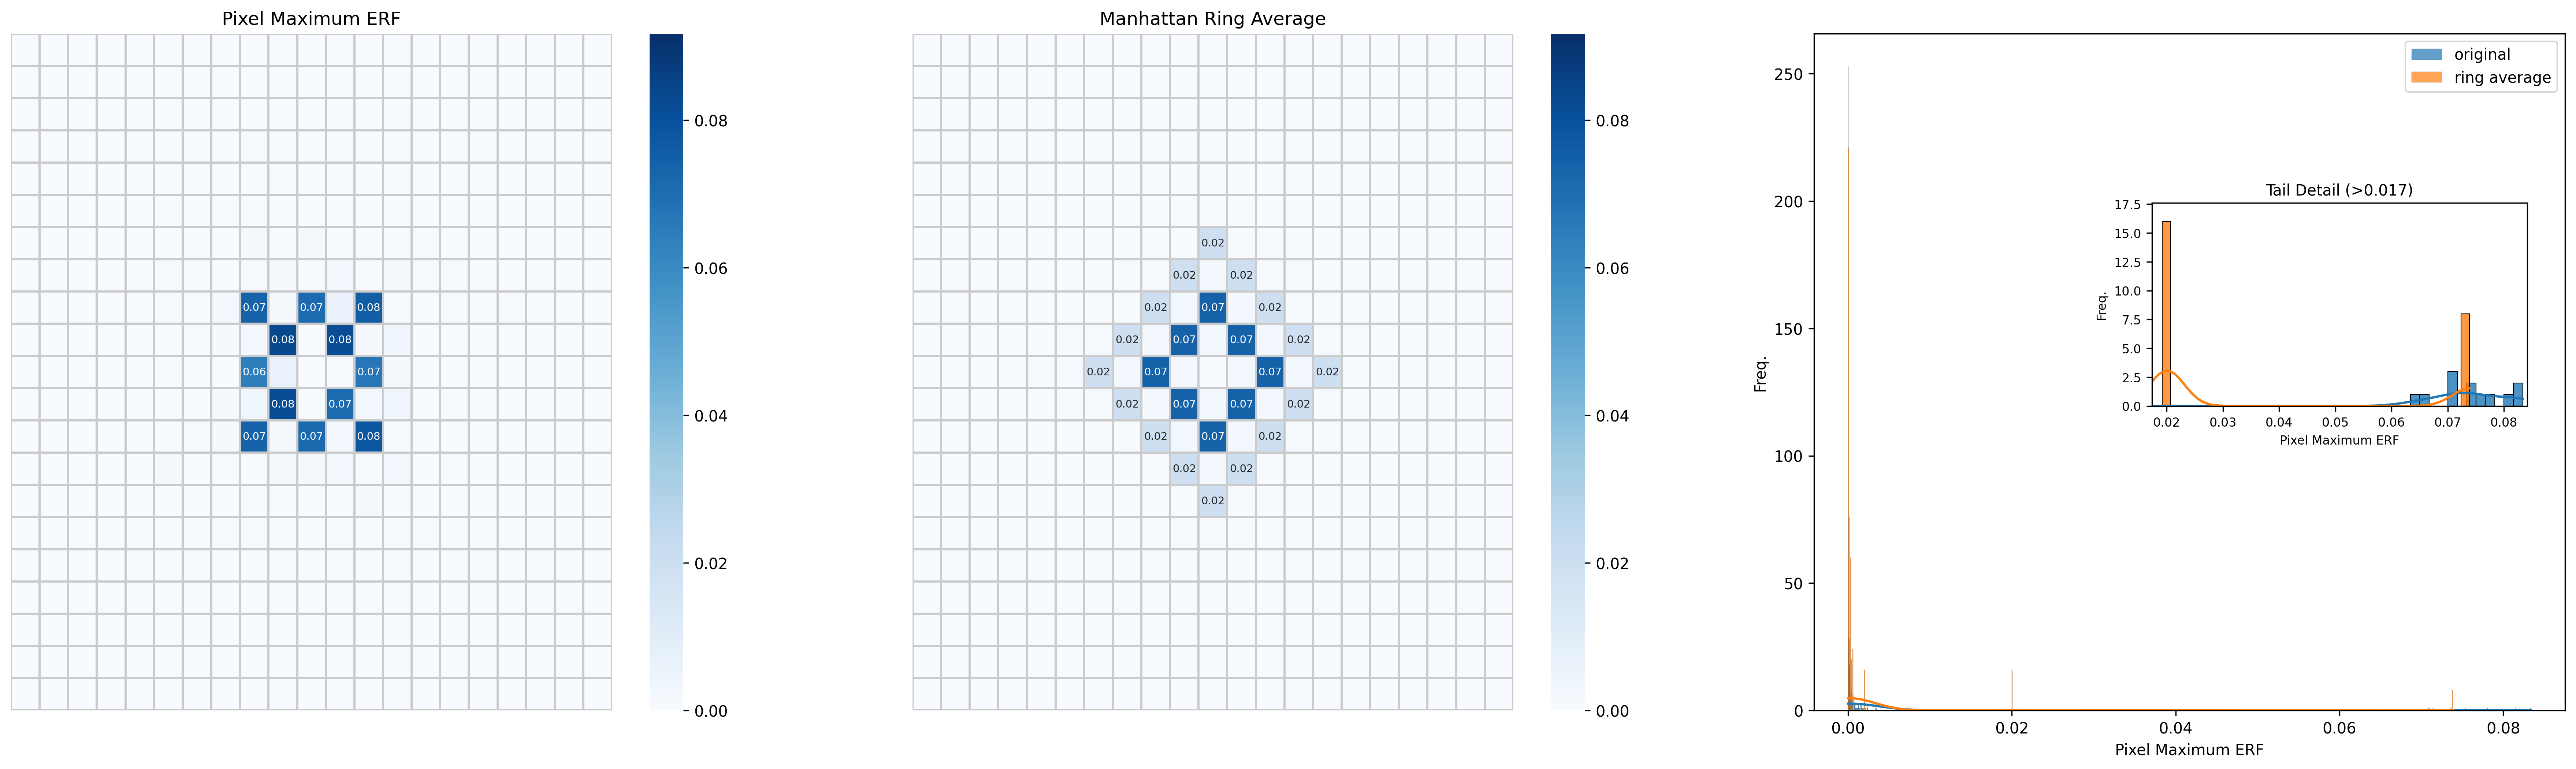

In [381]:

import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(30, 8), dpi=300)
# plt.suptitle(f"Maximum Absolute Pixel Effective Respective Fields of {model.__class__.__name__}\ntrained on {rule_str.replace('_', '/')} Data ({input_tensors.shape[0]} in-distribution samples)")

ax1 = plt.subplot(1, 3, 1)
annot_matrix = np.where(res_max >= 0.01, np.round(res_max, 2), '')
vmax = res_max.max() * 1.1
ax1.set_title("Pixel Maximum ERF")
sns.heatmap(res_max, cmap="Blues", annot=annot_matrix, fmt='', vmax=vmax, vmin=0, linewidths=1, linecolor="#cbcbcb", annot_kws={"size": 7}, ax=ax1)
ax1.set_xticks([]); ax1.set_yticks([])

ax2 = plt.subplot(1, 3, 2)

if np.linalg.norm(ring_average(res_max, "manhattan")-res_max) < np.linalg.norm(ring_average(res_max, "chebyshev")-res_max):
    ring_avg = ring_average(res_max, "manhattan")
    title_str = "Manhattan Ring Average"
else:
    ring_avg = ring_average(res_max, "chebyshev")
    title_str = "Chebyshev Ring Average"
    
ax2.set_title(title_str)
annot_matrix = np.where(ring_avg >= 0.01, np.round(ring_avg, 2), '')
sns.heatmap(ring_avg, cmap="Blues", annot=annot_matrix, fmt='', vmax=vmax, vmin=0, linewidths=1, linecolor="#cbcbcb", annot_kws={"size": 7}, ax=ax2)
ax2.set_xticks([]); ax2.set_yticks([])

ax3 = plt.subplot(1, 3, 3)
sns.histplot(res_max.flatten(), kde=True, ax=ax3, alpha=0.7, label="original")
sns.histplot(ring_avg.flatten(), kde=True, ax=ax3, alpha=0.7, label="ring average")
ax3.set_xlabel("Pixel Maximum ERF"); ax3.set_ylabel("Freq.")
ax3.legend()

ax_inset = ax3.inset_axes([0.45, 0.45, 0.5, 0.3])  # 右上角位置

# 绘制相同数据的局部放大（右侧长尾）
sns.histplot(res_max.flatten(), kde=True, ax=ax_inset, 
             alpha=0.8, bins=50, edgecolor='black', linewidth=0.5)
sns.histplot(ring_avg.flatten(), kde=True, ax=ax_inset, 
             alpha=0.8, bins=50, edgecolor='black', linewidth=0.5)

# 设置放大范围：根据你的数据调整这两个阈值
th = res_max.max()*0.2 + res_max.mean() * 0.3
ax_inset.set_xlim(th, res_max.max()*1.01)  # 只看大于threshold的部分
ax_inset.set_ylim(0, 
                  max(5, 
                      Counter(np.concatenate((res_max[res_max > th].flatten(), 
                                              ring_avg[ring_avg > th].flatten()))
                              ).most_common(1)[0][1]) * 1.1)  # 根据实际低频区域调整y轴上限

# 子图美化
ax_inset.set_title(f'Tail Detail (>{th:.2g})', fontsize=10, pad=5)
ax_inset.set_xlabel('Pixel Maximum ERF', fontsize=8)
ax_inset.set_ylabel('Freq.', fontsize=8)
ax_inset.tick_params(labelsize=8)
# ax_inset.patch.set_facecolor("#d2e4ff")  # 淡红背景突出显示
# ax_inset.spines['top'].set_color('darkred')
# ax_inset.spines['right'].set_color('darkred')

# 添加连接线（自动高亮主图中被放大的区域）
# ax3.indicate_inset_zoom(ax_inset, linewidth=1, alpha=0.5)

# 可选：在主图中添加半透明矩形标记被放大区域
# ax3.axvspan(threshold, res_max.max(), alpha=0.1, zorder=0)

plt.show()

fig.savefig(f"./{model.__class__.__name__}_{rule_str}.pdf", transparent=True, dpi=400, format="pdf")

In [382]:
def erf_threshold_by_energy(erf_matrix):
    
    center_point = np.zeros_like(erf_matrix)
    center_point[erf_matrix.shape[0]//2, erf_matrix.shape[1]//2] = True
    res = []
    seen = set()
    
    for target_energy in sorted(np.linspace(0, 1, 10), reverse=True):
        if target_energy < 1e-3 or target_energy > 1 - 1e-3:
            continue
        
        flat = res_max.flatten()
        sorted_indices = np.argsort(flat)[::-1]
        sorted_values = flat[sorted_indices]
        cumsum = np.cumsum(sorted_values)
        cumsum /= cumsum[-1]
        threshold_idx = np.searchsorted(cumsum, target_energy)
        threshold = sorted_values[threshold_idx]
        mask = res_max >= threshold
        
        mask = ((np.rot90(mask, 1) + np.rot90(mask, 3) + mask + np.rot90(mask, 2)) / 4 + center_point) > 0
        
        if mask.tobytes() in seen:
            continue
        else:
            seen.add(mask.tobytes())
            res.append((mask, threshold, target_energy))
    
    return res

In [383]:
res = erf_threshold_by_energy(res_max)

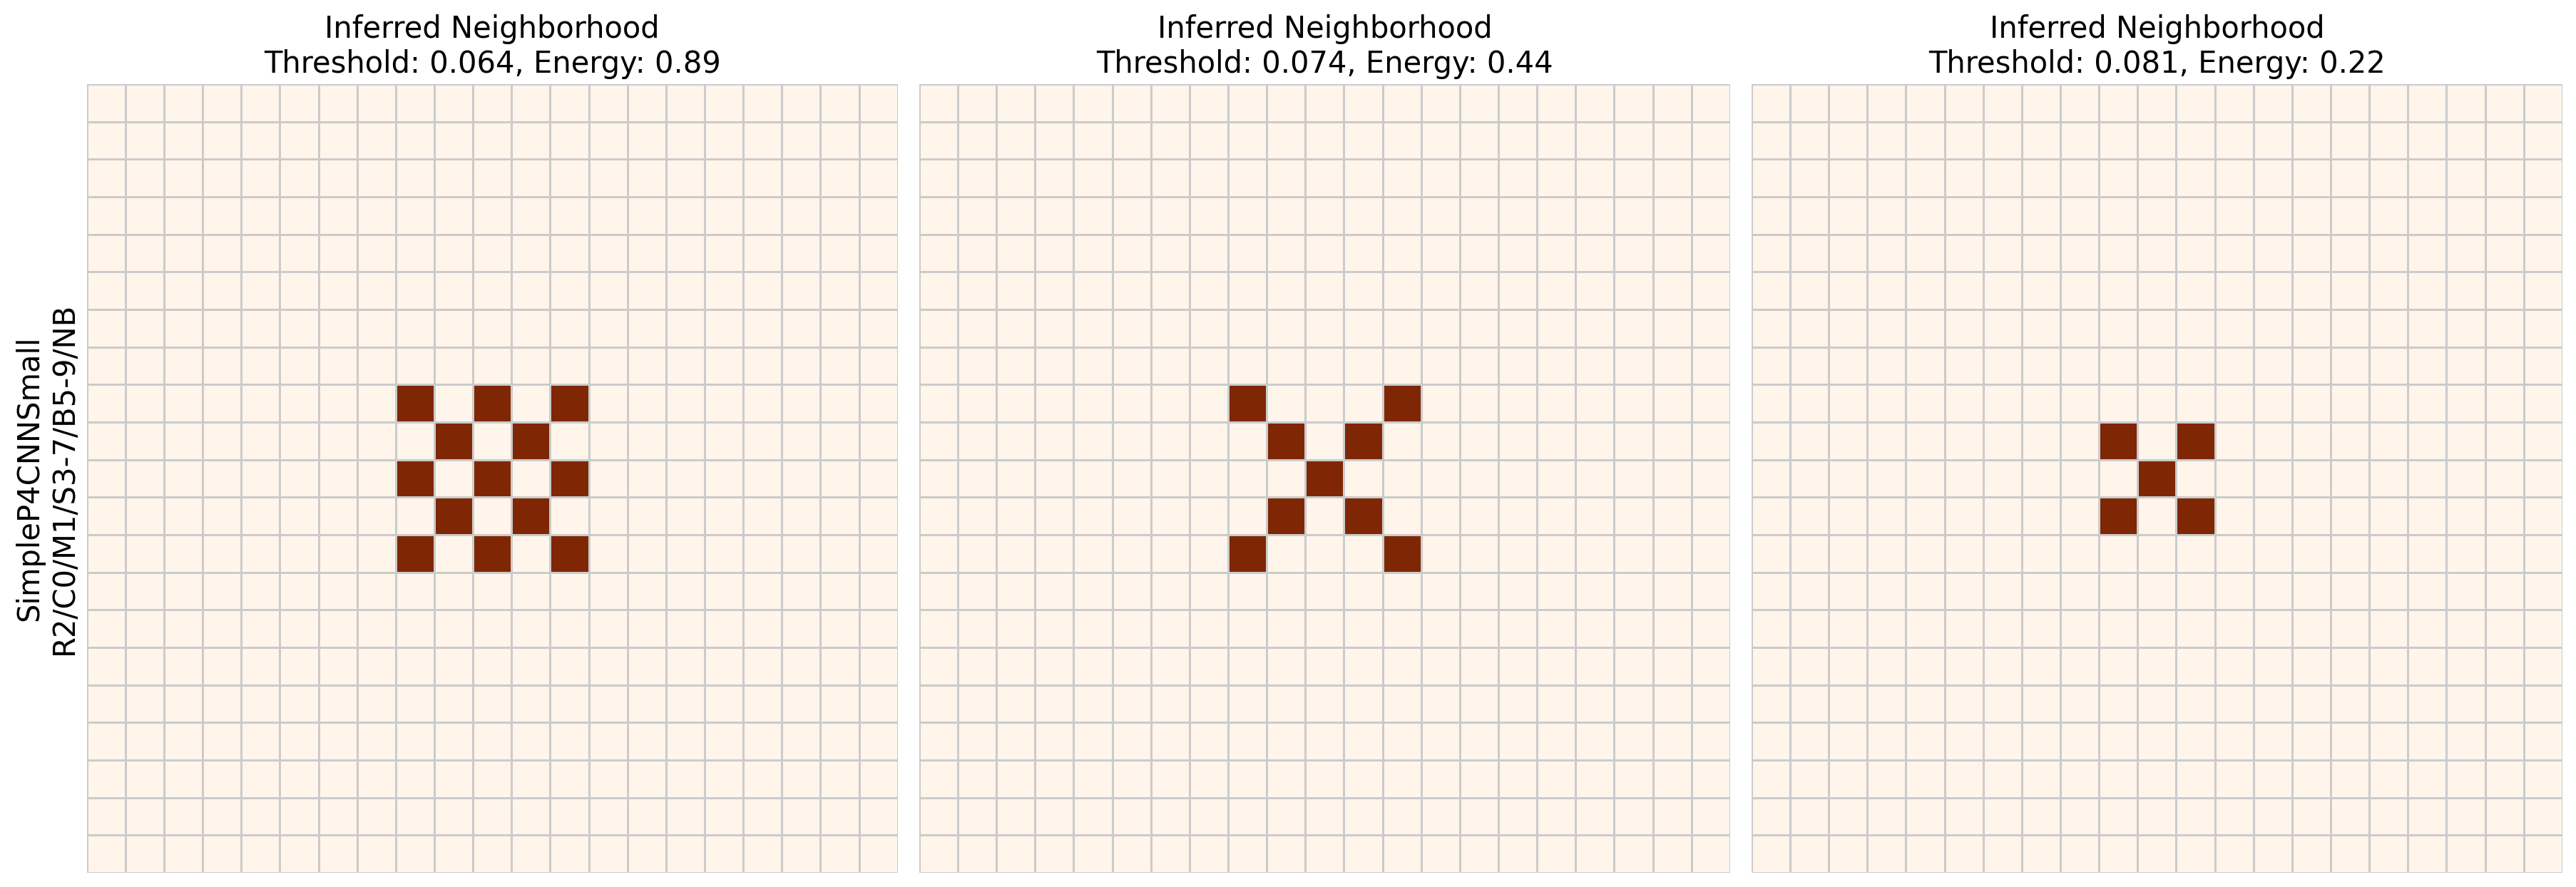

In [384]:
# plot the mask under different energy threshold

plt.figure(figsize=(24, 12), dpi=200)

for i, (mask, threshold, e) in enumerate(res):
    plt.subplot(2, 4, i+1)
    sns.heatmap(mask, cmap='Oranges', linewidths=1, linecolor="#cbcbcb", cbar=False)
    plt.title(f"Inferred Neighborhood\nThreshold: {threshold:.2g}, Energy: {e:.2g}", {'fontsize': 15})
    plt.xticks([]); plt.yticks([]);
    
    if i == 0:
        plt.ylabel(f"{model.__class__.__name__}\n{rule_str.replace('_', '/')}", rotation=90, fontdict={'fontsize': 15})

plt.tight_layout()
plt.show()

In [398]:
neighborhood = res[1][0]
w, h = neighborhood.shape

Text(0.5, 1.0, '\nWeight of Neighborhood Complement\n')

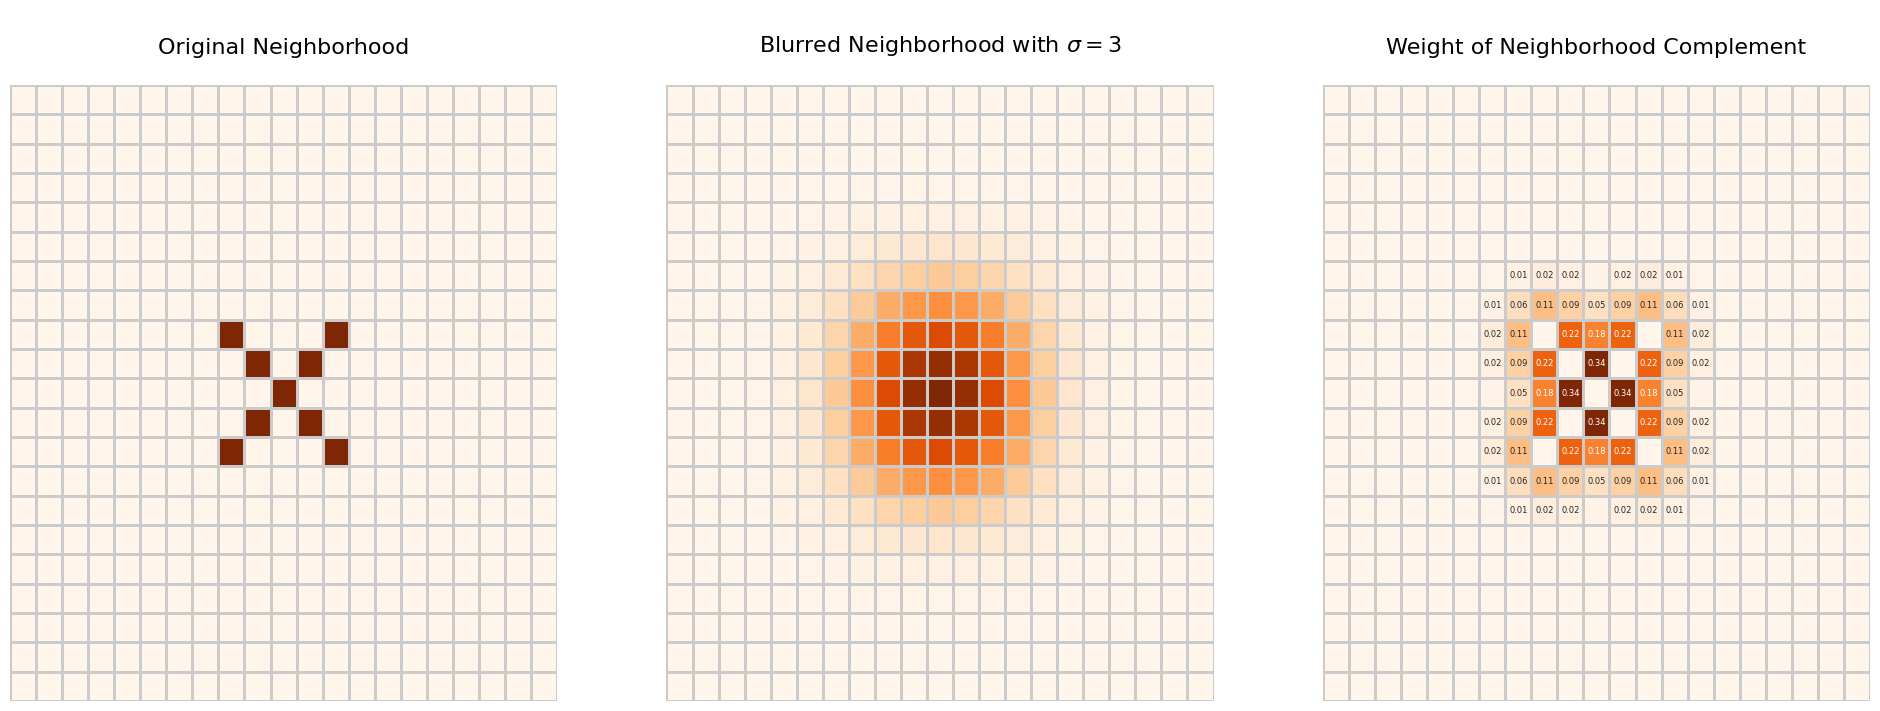

In [403]:
from scipy.ndimage import gaussian_filter

plt.figure(figsize=(24, 8))

plt.subplot(1, 3, 1)
sns.heatmap(neighborhood, cmap='Oranges', linewidths=1, linecolor="#cbcbcb", cbar=False)
plt.title("\nOriginal Neighborhood\n", fontsize=16)
plt.xticks([]); plt.yticks([]);

plt.subplot(1, 3, 2)
sns.heatmap(gaussian_filter(neighborhood.astype(float), sigma=2), cmap='Oranges', linewidths=1, linecolor="#cbcbcb", cbar=False)
plt.xticks([]); plt.yticks([]);
plt.title("\nBlurred Neighborhood with $\\sigma=3$\n", fontsize=16)

blurred = gaussian_filter(neighborhood.astype(float), sigma=1)
blurred[(neighborhood > 0.5) | (blurred < 1e-3)] = 0
annot_matrix_b = np.where(blurred >= 0.01, np.round(blurred, 2), '')
plt.subplot(1, 3, 3)
sns.heatmap(blurred, cmap='Oranges', annot=annot_matrix_b, fmt='', linewidths=1, linecolor="#cbcbcb", cbar=False, annot_kws={"size": 6})
plt.xticks([]); plt.yticks([]);
plt.title(f"\nWeight of Neighborhood Complement\n", fontsize=16)

<Axes: >

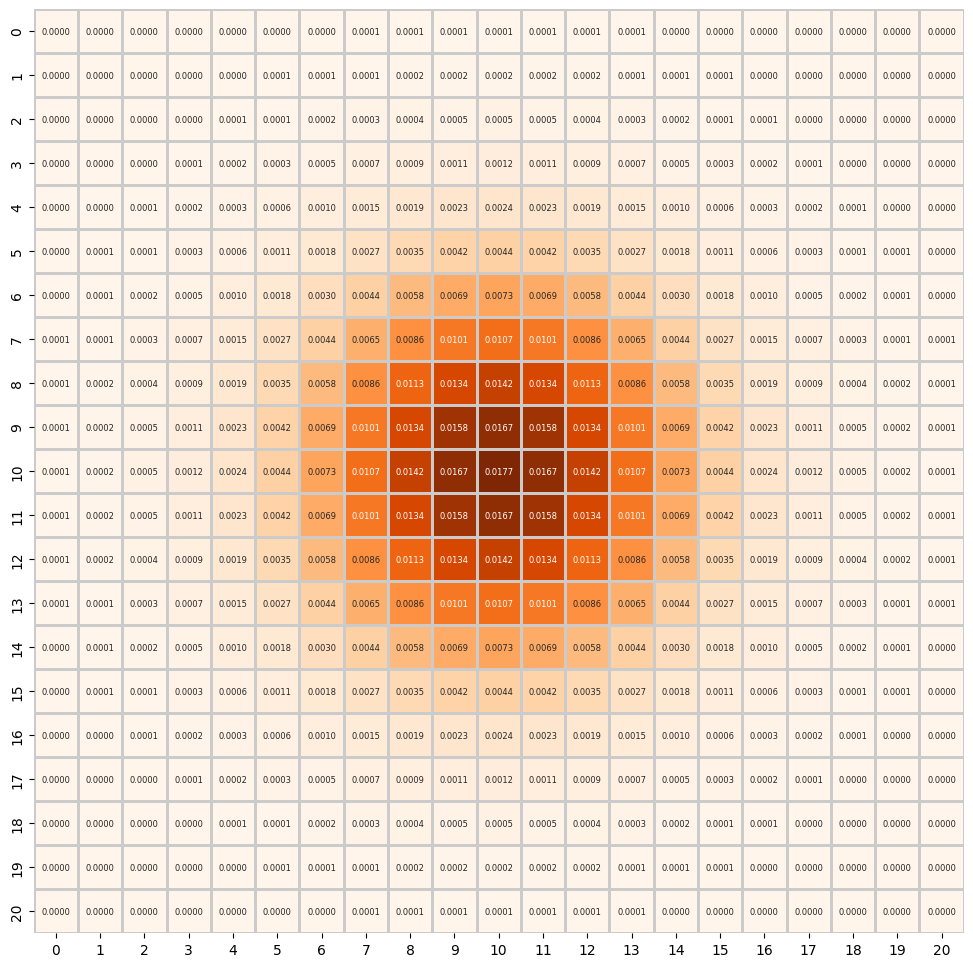

In [416]:
a = np.zeros_like(neighborhood)
n,m = a.shape
a[n//2, m//2] = 1

plt.figure(figsize=(12, 12))
sns.heatmap(gaussian_filter(a.astype(float), sigma=3), cmap='Oranges', annot=True, fmt='.4f', linewidths=1, linecolor="#cbcbcb", cbar=False, annot_kws={"size": 6})

In [400]:
def get_nc_weights(n: np.ndarray, sigma=3) -> np.ndarray:
    blurred = gaussian_filter(n.astype(float), sigma=sigma)
    blurred[(n > 0.5) | (blurred < 1e-3)] = 0
    return blurred / blurred.sum()

In [388]:
res[1][0]

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

(50, 50)
(50, 50)


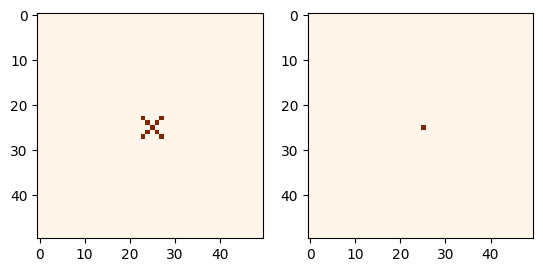

In [389]:
target_shape = (50, 50)
neighborhood_full = np.zeros(target_shape, dtype=bool)
center = target_shape[0] // 2

neighborhood_full[center-w//2:center+w//2+1, center-h//2:center+h//2+1] = neighborhood

center_point = np.zeros_like(neighborhood_full)
center_point[center, center] = True

plt.subplot(1, 2, 1)
plt.imshow(neighborhood_full, cmap="Oranges"); print(neighborhood_full.shape)
plt.subplot(1, 2, 2)
plt.imshow(center_point, cmap="Oranges"); print(center_point.shape)

In [390]:
from train_test import apply_rotation, apply_translation

apply_translation(apply_rotation(torch.from_numpy(neighborhood_full)[None, ...], 90)[0], (10, 10))

((tensor([[False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          ...,
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False]]),),
 (10, 10))

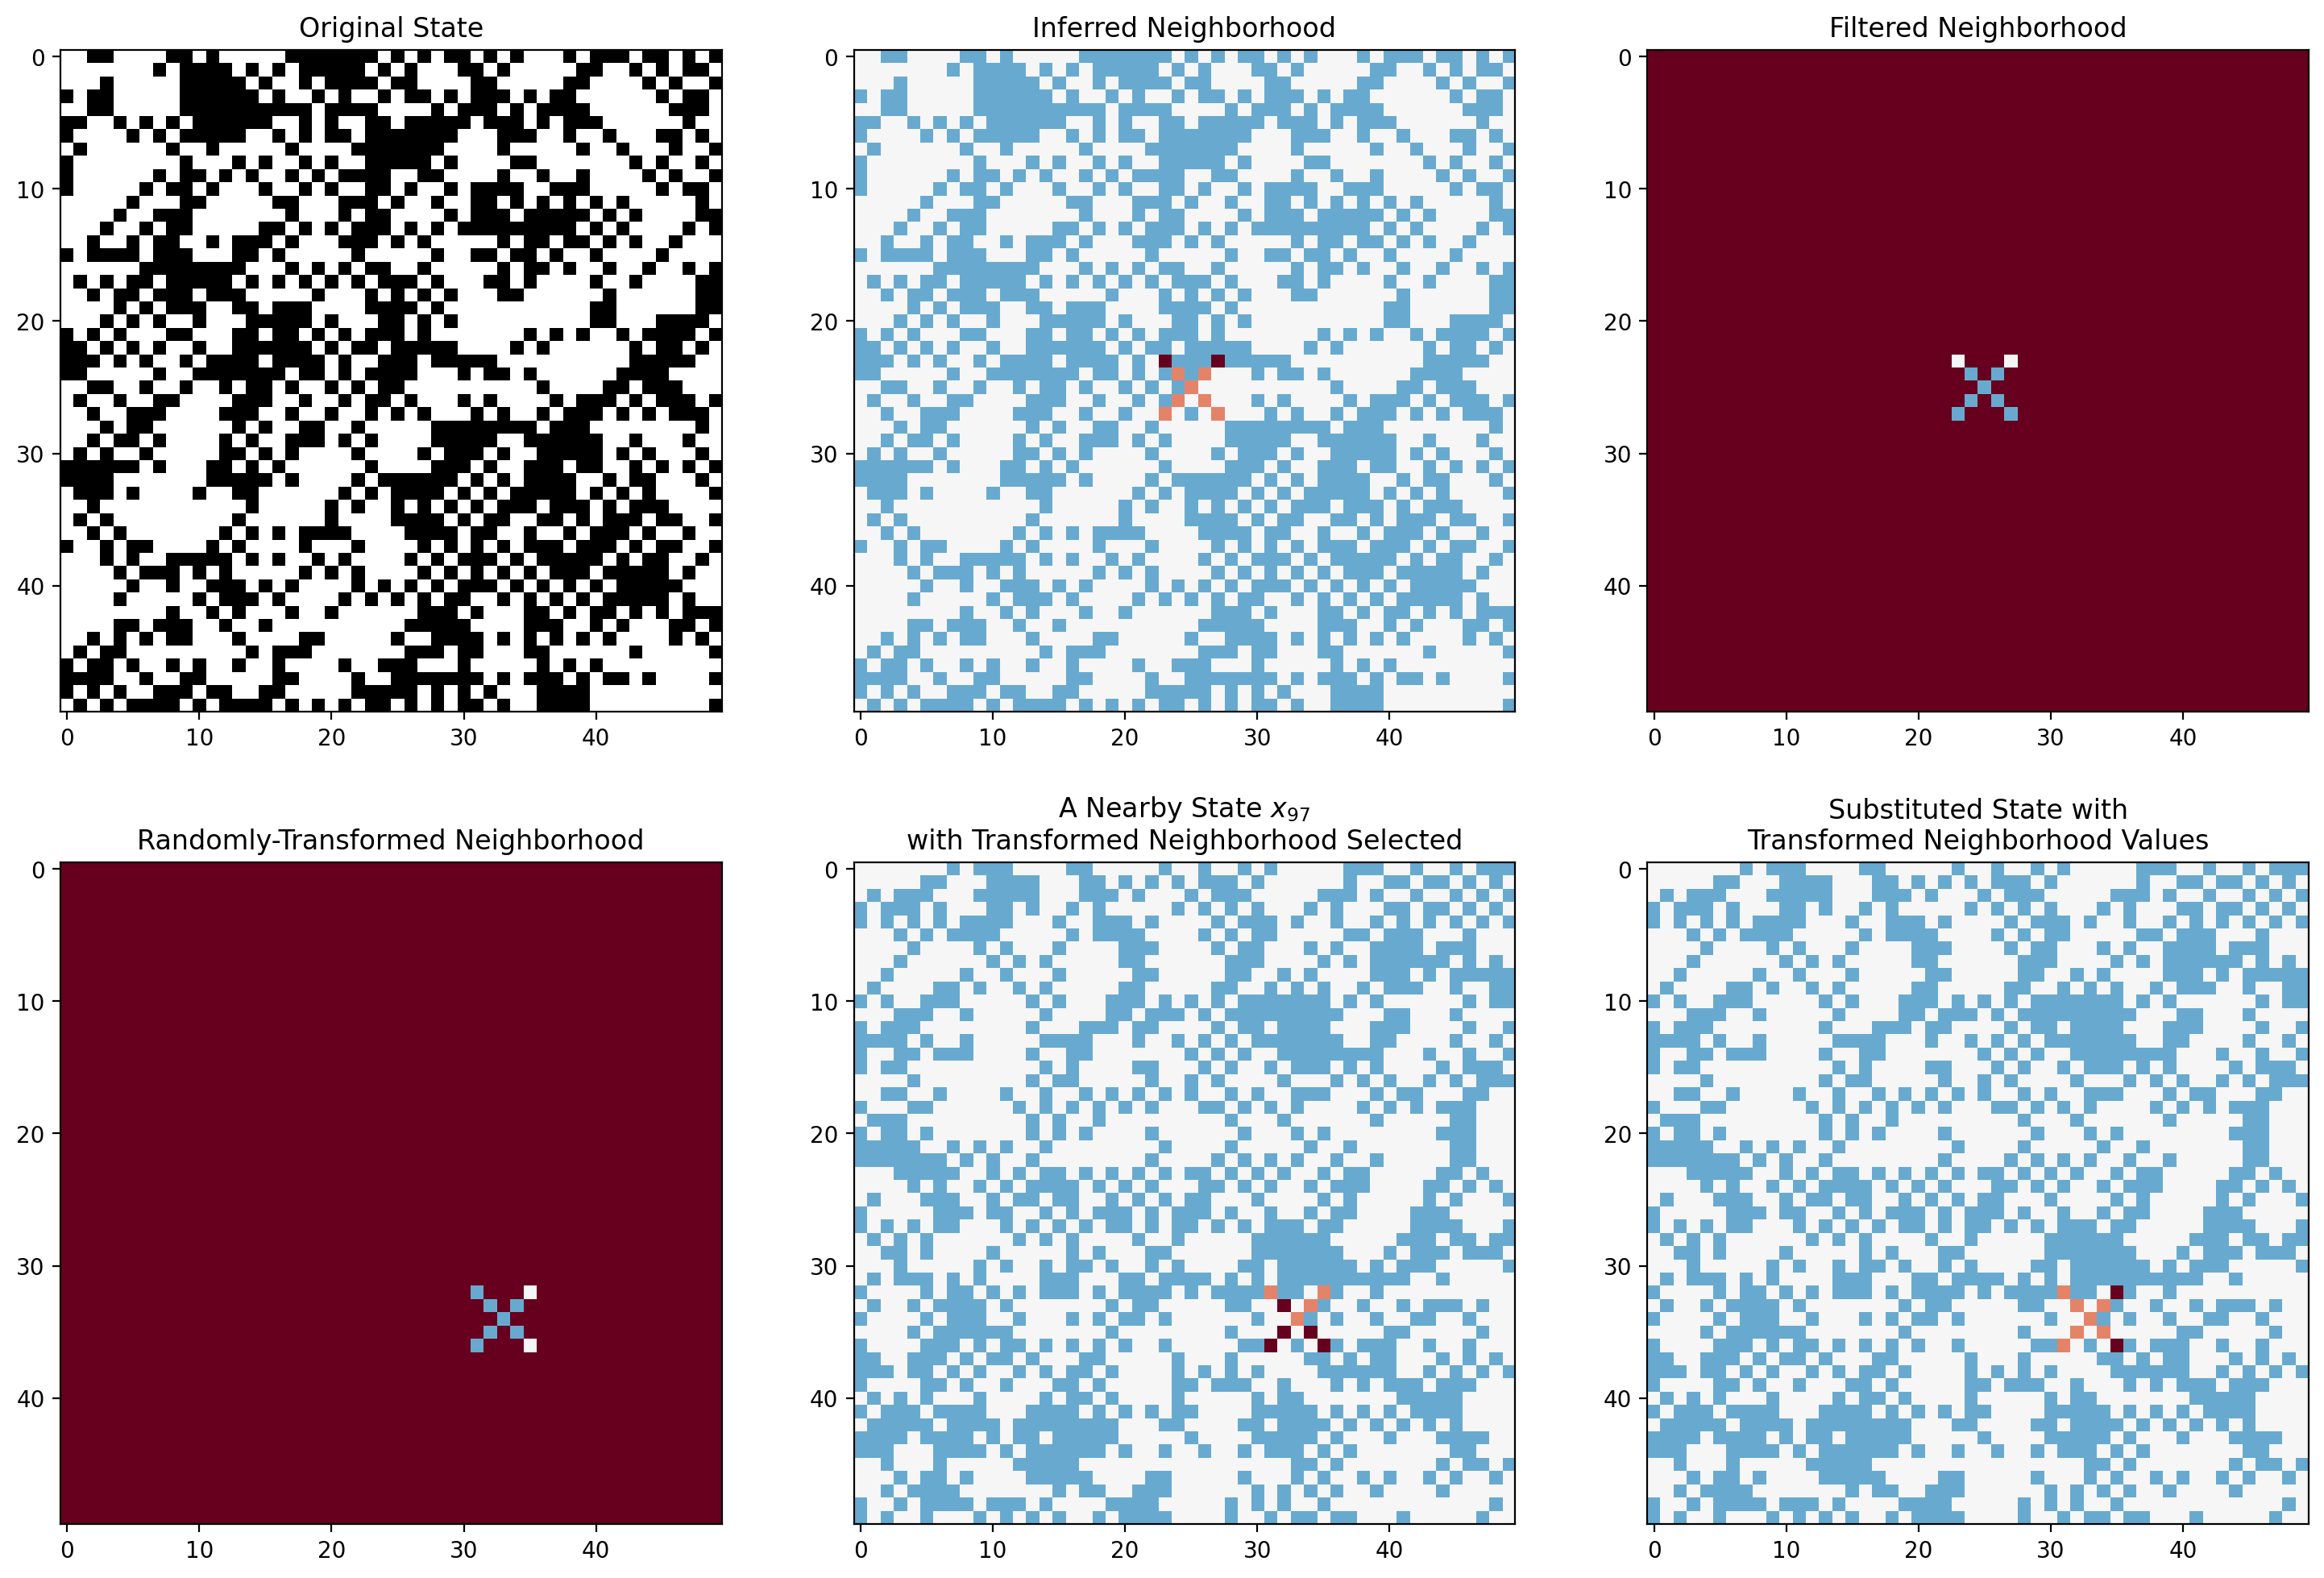

In [391]:
from copy import deepcopy

arr = deepcopy(dataset.arr_list[0][102, :50, :50])

plt.figure(figsize=(18, 12), dpi=200)

plt.subplot(2, 3, 1)
plt.title("Original State")
plt.imshow(arr, cmap="Grays")
plt.subplot(2, 3, 2)
plt.title("Inferred Neighborhood")
plt.imshow(arr - 2*neighborhood_full, cmap="RdBu", vmax=2, vmin=-2)
plt.subplot(2, 3, 3)
plt.title("Filtered Neighborhood")
filtered = deepcopy(arr).astype(float)
filtered[~neighborhood_full] = -2
plt.imshow(filtered, cmap="RdBu", vmax=2, vmin=-2)

# =============== randomly transform and 
t_neighbor, t_filtered, t_center = apply_translation(apply_rotation((
                                                torch.from_numpy(neighborhood_full)[None, ...], 
                                                torch.from_numpy(filtered)[None, ...], 
                                                torch.from_numpy(center_point)[None, ...]
                                        ))[0])[0]
t_neighbor, t_filtered, t_center = t_neighbor[0].numpy(), t_filtered[0].numpy(), t_center[0].numpy()

plt.subplot(2, 3, 4)
plt.title("Randomly-Transformed Neighborhood")
plt.imshow(t_filtered, cmap="RdBu", vmax=2, vmin=-2)

diff_ran = np.random.randint(-10, 11, size=1)
arr1_near = deepcopy(dataset.arr_list[0][100 + diff_ran[0], :50, :50])

plt.subplot(2, 3, 5)
plt.title("A Nearby State $x_{" + str(100 + diff_ran[0]) + "}$\nwith Transformed Neighborhood Selected")
plt.imshow(arr1_near - 2*t_neighbor, cmap="RdBu", vmax=2, vmin=-2)

n_filtered = deepcopy(arr1_near)
n_filtered[t_neighbor] = t_filtered[t_neighbor]
plt.subplot(2, 3, 6)
plt.title("Substituted State with\nTransformed Neighborhood Values")
plt.imshow(n_filtered - 2*t_neighbor, cmap="RdBu", vmax=2, vmin=-2)

In [392]:
res = model(torch.from_numpy(arr)[None, None, ...].float().to(device)).detach().cpu().numpy()[0][0]
res[center_point] > 0

array([ True])

In [393]:
res = model(torch.from_numpy(n_filtered)[None, None, ...].float().to(device)).detach().cpu().numpy()[0][0]
res[t_center] > 0

array([ True])

In [394]:
findmax_2d = lambda x: np.where(x == x.max())

In [395]:
res

array([[ 1.1106e+01, -7.0622e+00,  1.9035e+01, ...,  7.3371e+00, -1.0432e+01, -1.1011e-01],
       [-7.7831e-03,  2.6706e+01, -7.1090e+00, ...,  1.8452e+01,  2.1873e+01,  1.8005e+01],
       [ 1.0359e+01, -4.1814e-02, -5.5755e+00, ...,  4.1756e+01,  1.9357e+01,  2.3052e+01],
       ...,
       [ 2.3827e+00,  2.0240e+01, -5.9745e-01, ..., -6.4011e+00,  1.9597e+01, -7.1339e+00],
       [-9.5066e+00, -7.2361e+00,  2.8758e+01, ...,  2.2352e+00, -1.3578e+01,  1.1388e+01],
       [-1.3373e+01,  2.7454e+01, -1.3129e+01, ..., -4.3346e+00, -5.1804e+00,  2.0508e+00]],
      dtype=float32)

* Given fixed neighborhood to test
* Choose a frame and apply the neighborhood to this frame. Calculate full neighborhood `neighborhood_full`, center point `center_point`, neighborhood compliment weight `nc_weight` and filtered array neighborhood `filtered`. Note that `neighborhood_full` is a boolean matrix indicating the neighborhood area, while `filtered` consists of actual neighborhood state of center point in this frame.
* Randomly transform the aforementioned items along with the chosen frame to a new configuration.
* Choose another frame, and apply the transferred neighborhood to this frame. Calculate the difference between this frame with the transferred original frame with respect to transferred neighborhood compliment weight `t_ncw`. This step ensures that random transformation and attachment changes the state of neighborhood compliment evidently.
* Compare the prediction of the center cell given the original setting and the perturbed setting, test whether they're different. For given original neighborhood and moved ones, we calculate the KL divergence between prediction of perturbed neighborhoods w.r.t. the original ones, which gives a series of points ${(d, k)}$ in which $d$ denotes the preturbing difference and $k$ denotes the KL divergence. For each sample of original neighborhood, we consider performing a linear regression on $X=d$ and $y=\log(k-\min\{k\})$. This yields a series of fitted slopes as ATEs given each original period.
* Consider the 25%, 50% and 75% percentile of the absolute value of ATEs, the overall causality score of perturbing neighborhood compliment is given by $S = 3p_{25} + 2p_{50} + p_{75}$, and select the neighborhood pattern that has the lowest causality score.

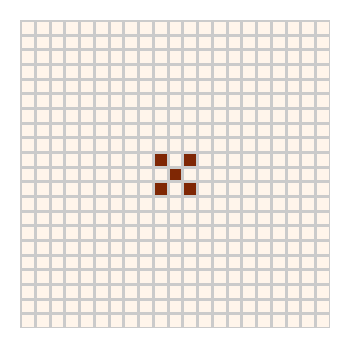

 25%|██▌       | 2500/10000 [00:07<00:22, 327.81it/s]


KeyboardInterrupt: 

In [396]:
from torch.nn import KLDivLoss
from tqdm import tqdm
import statsmodels.api as sm

res = erf_threshold_by_energy(res_max)

ll = []

n_num = 200
patch_num = 50

for n in res[::-1]:
    neighborhood = n[0]
    plt.figure(figsize=(2, 2), dpi=200)
    sns.heatmap(neighborhood, cmap='Oranges', linewidths=1, linecolor="#cbcbcb", cbar=False)
    plt.xticks([]); plt.yticks([]);
    plt.show()
    
    treatment_res = [{
        "treatment": [],
        "outcome": []
    } for _ in range(n_num)]
    
    torch.cuda.empty_cache()
    
    with tqdm(total=n_num * patch_num) as pbar:
        for ni in range(n_num):
            traj_index = np.random.randint(0, len(dataset.arr_list)-1)
            traj = dataset.arr_list[traj_index]
            slice_index = np.random.randint(0, len(traj)-1)
            arr = traj[slice_index].copy()

            target_shape = arr.shape
            neighborhood_full = np.zeros(target_shape, dtype=bool)
            center = target_shape[0] // 2
            neighborhood_full[center-w//2:center+w//2+1, center-h//2:center+h//2+1] = neighborhood
            center_point = np.zeros_like(neighborhood_full)
            center_point[center, center] = True
            nc_weight = get_nc_weights(neighborhood_full)

            filtered = arr.copy().astype(float)
            filtered[~neighborhood_full] = -2

            # =============== randomly transform and

            # print(filtered[filtered > -2], end=' --> ')
            # print(model(torch.from_numpy(arr)[None, None, ...].float().to(device)).shape)
            # print(o_res:=model(torch.from_numpy(arr)[None, None, ...].float().to(device))[:, :, center_point], o_res.shape)
            original_output = (model(torch.from_numpy(arr)[None, None, ...].float().to(device))[:, :, center_point].reshape(-1)).detach().cpu()

            n_filters = []
            n_centers = []
            for _ in range(patch_num):
                treatment_diff = 0
                treatment_trials = 0
                
                # find effective treatment
                while treatment_diff < 0.2 and treatment_trials < 6000:
                    t_neighbor, t_filtered, t_center, t_ncw, t_arr = apply_translation(apply_rotation((
                                                                    torch.from_numpy(neighborhood_full)[None, ...], 
                                                                    torch.from_numpy(filtered)[None, ...], 
                                                                    torch.from_numpy(center_point)[None, ...],
                                                                    torch.from_numpy(nc_weight)[None, ...],
                                                                    torch.from_numpy(arr)[None, ...]
                                                            ))[0])[0]
                    t_neighbor, t_filtered, t_center, t_ncw, t_arr = t_neighbor[0].numpy(), t_filtered[0].numpy(), t_center[0].numpy(), t_ncw[0].numpy(), t_arr[0].numpy()

                    # sample another frame as treated neighborhood compliment
                    near_index = np.random.randint(0, len(traj)-1)
                    arr1_near = np.squeeze((traj[near_index].copy()))
                    
                    #              transformed neighborhood compliment weight
                    treatment_diff = (t_ncw * (t_arr.astype(float) - arr1_near.astype(float)) ** 2).sum()
                    
                    treatment_trials += 1
                    # print(treatment_trials, treatment_diff, end="\r")

                treatment_res[ni]["treatment"].append(treatment_diff)
                
                n_filtered = arr1_near.copy()
                
                n_filtered[t_neighbor] = t_filtered[t_neighbor]
                
                n_filters.append(n_filtered)
                n_centers.append(t_center)
                
                pbar.update(1)
            
            n_filters = torch.from_numpy(np.stack(n_filters))[:, None, ...].float()
            n_centers = torch.from_numpy(np.stack(n_centers))[:, None, ...]
            
            # [100, 200, 200]
            res_s = (model(n_filters.to(device))[:, :, center_point].reshape(patch_num, 2)).detach().cpu()
            
            avg_kl_div = list(KLDivLoss(log_target=True, reduction="none")(res_s, original_output.reshape(1, 2).repeat(patch_num, 1)).sum(1).reshape(-1).detach().cpu().numpy())
            treatment_res[ni]["outcome"].extend(avg_kl_div)
            # print(kl_div_ls)
    
    # plt.figure(figsize=(4, 3), dpi=200)
    
    ate_ls = []
    
    for d in treatment_res:
        # sns.scatterplot(x=np.array(d["treatment"]), y=np.array(d["outcome"]), alpha=0.7)
        
        X = d["treatment"]  # 处理变量 T
        y = np.log(np.array(d["outcome"]) - min(d["outcome"]) + 1e-6)    # 结果变量 Y

        # 添加常数项（截距）
        X = sm.add_constant(X)

        # 拟合 OLS: Y = α + β·T + ε
        sm_model = sm.OLS(y, X).fit()

        # 提取 ATE（即斜率系数 β）
        ate = sm_model.params[1]  # 或者 model.params['x1']
        ate_ci = sm_model.conf_int(alpha=0.05)[1]  # 95% 置信区间

        # print(f"ATE (平均处理效应): {ate:.6f}")
        
        ate_ls.append(ate)
        
    print(p:=np.percentile(np.abs(np.array(ate_ls)), [25, 50, 75]))
    print(np.dot(p, np.array([3, 2, 1])))
    
    # plt.xlabel("treatment")
    # plt.ylabel("outcome")
    # plt.semilogy()
    # plt.show()

In [ ]:
np.array(d["outcome"]).min()

-3.0157168